#MACHINE LEARNING - MODELOS DE IA 💻

# **ARBOL DE DECISION** 🌳






---
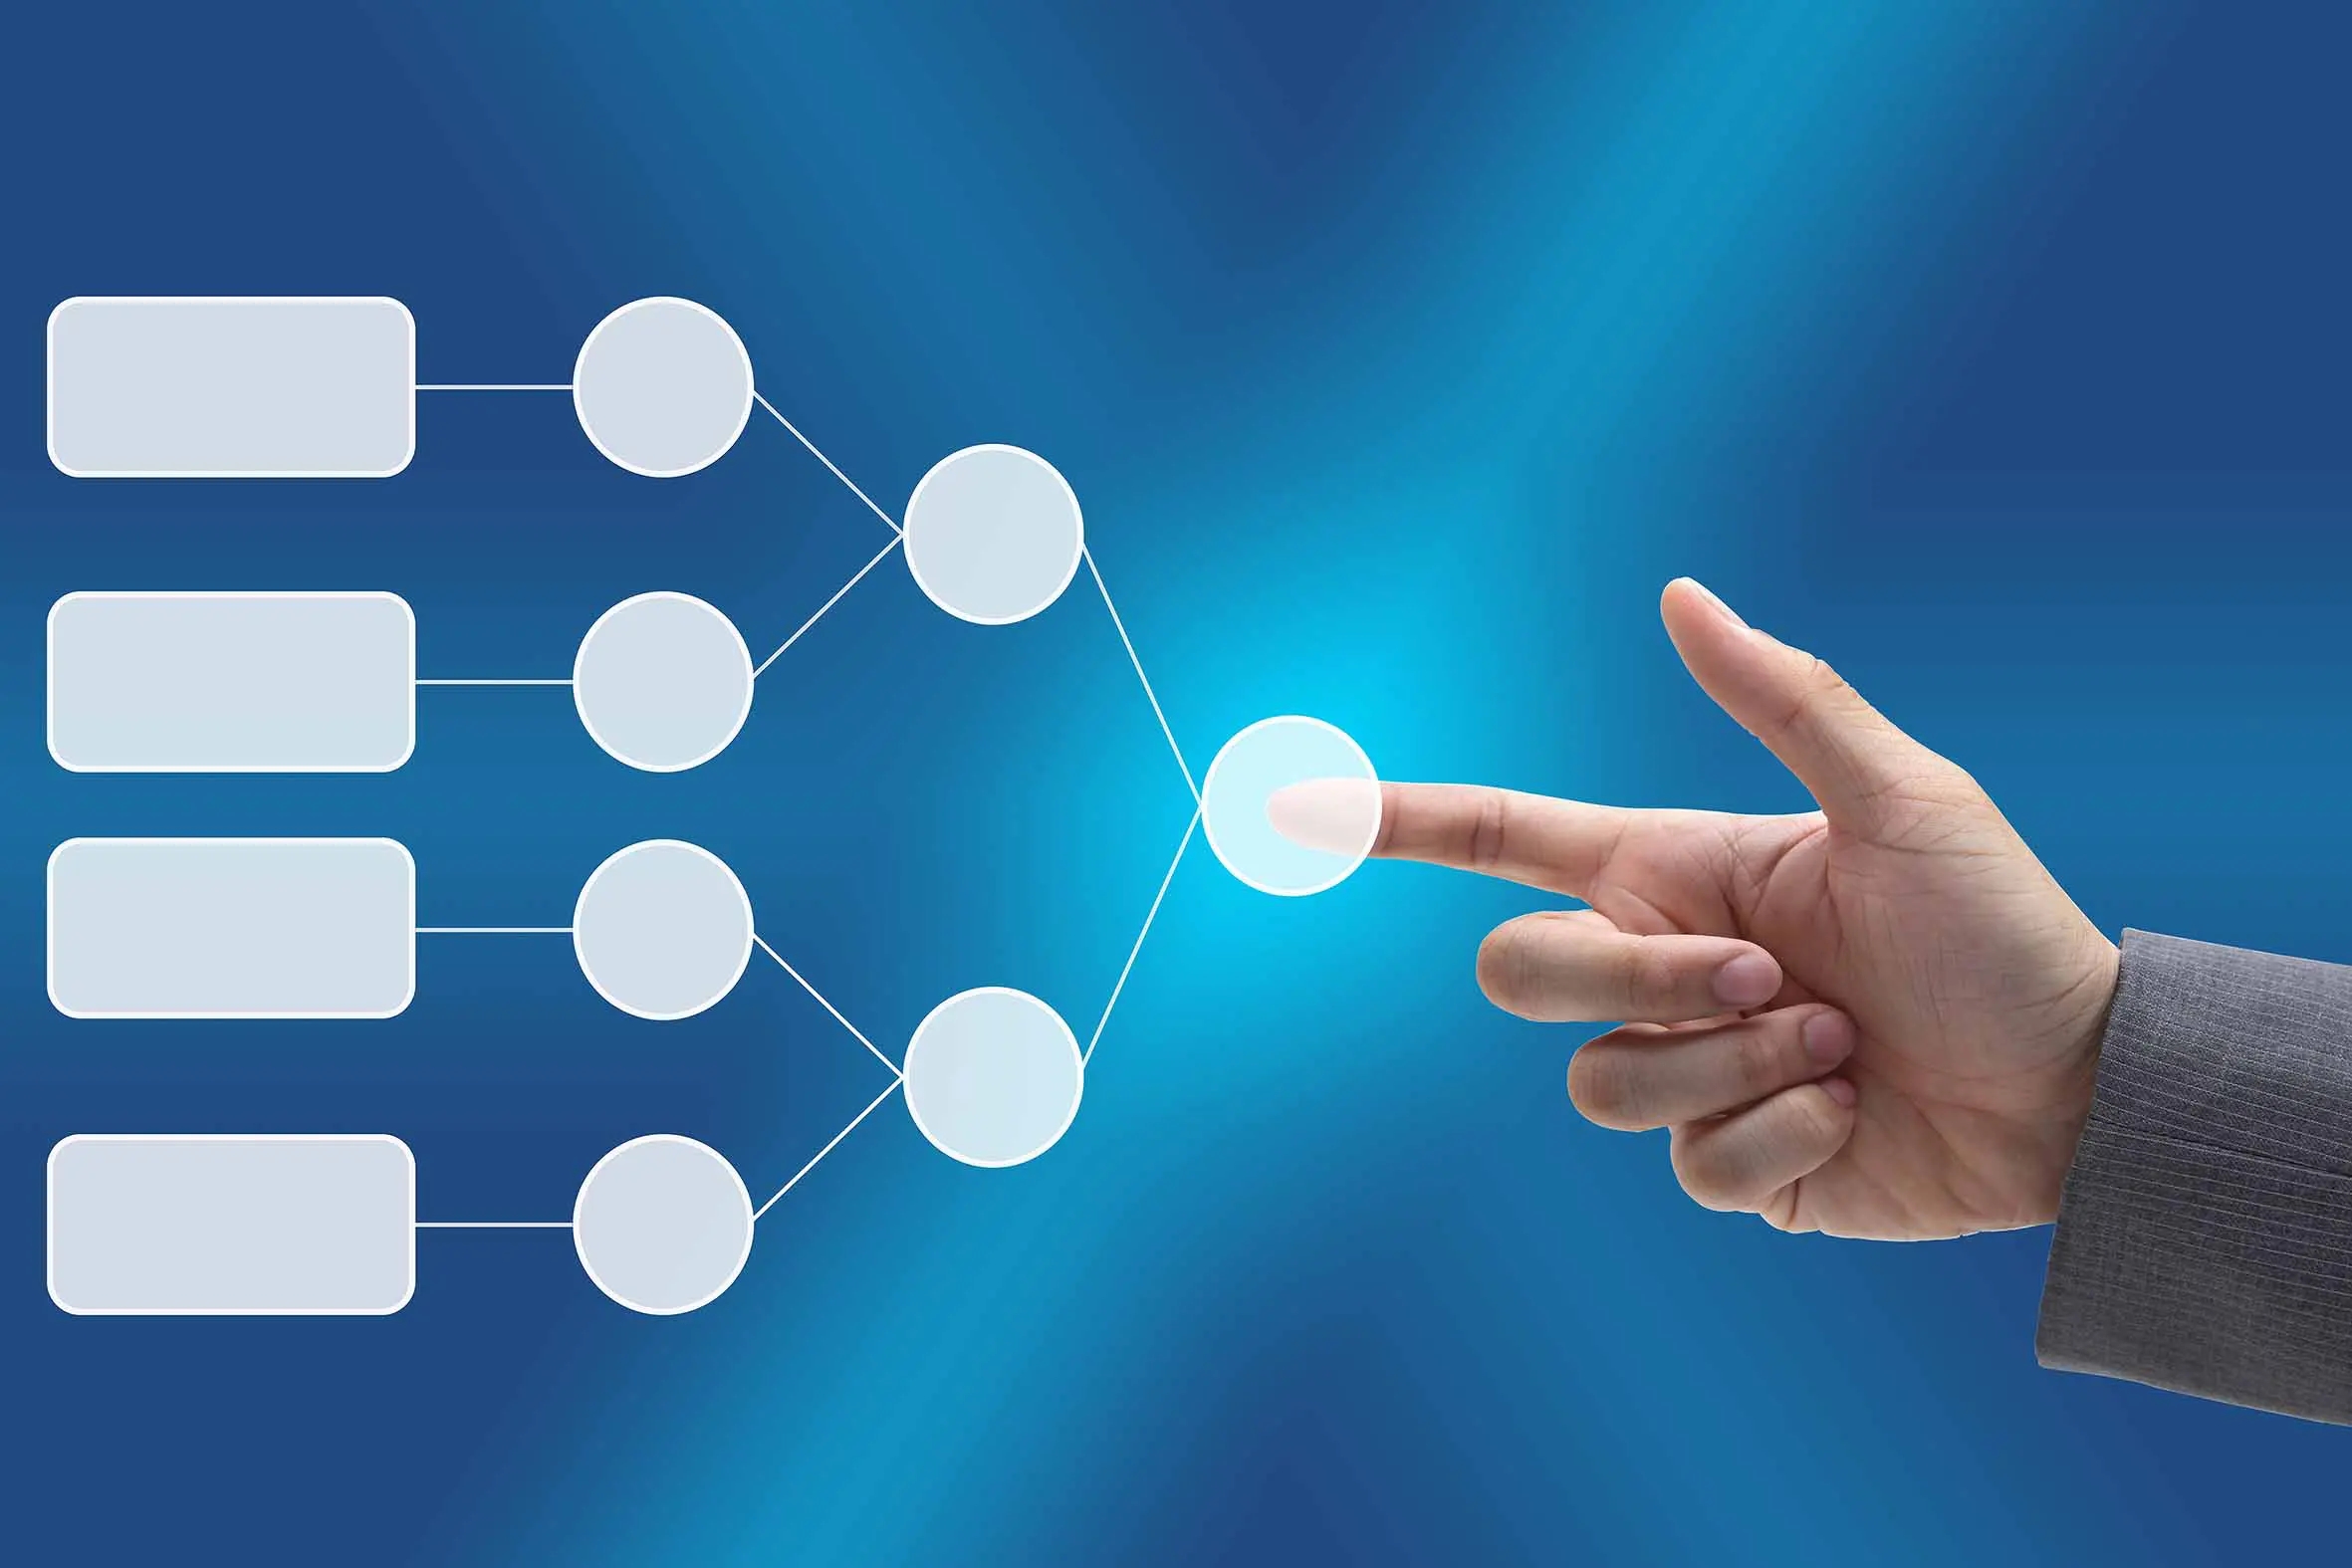


---

BY: GRUPO #3



`Arbol de clasificacion` ***and***  ```KNN```








link dataset : https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset?resource=download

##Importaciones ⬇

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             ConfusionMatrixDisplay,
                             precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve)

#***Conjunto de datos de predicción de aprobación de préstamos***

##Carga dataset 📋

In [ ]:
df = pd.read_csv("loan_approval_dataset.csv")
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


##Analisis de datos 🔎

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [ ]:
print("Cantidad de filas duplicadas:", df.duplicated().sum())

Cantidad de filas duplicadas: 0


In [ ]:
print(df.columns)

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')


In [ ]:
df.columns = df.columns.str.strip().str.lower()

##Balance de clases : Aprobado/rechazado + proporcion ⚖

In [ ]:
df["loan_status"].value_counts()

,count
loan_status,
Approved,2656
Rejected,1613


In [ ]:
df["loan_status"].value_counts(normalize=True)

,proportion
loan_status,
Approved,0.62216
Rejected,0.37784


##Codificación de variables categóricas ⌨

In [ ]:
encoder = LabelEncoder()

df["education"] = encoder.fit_transform(df["education"])
df["self_employed"] = encoder.fit_transform(df["self_employed"])
df["loan_status"] = encoder.fit_transform(df["loan_status"])

##Separacion de variables

In [ ]:
X = df.drop(columns=["loan_id", "loan_status"])
y = df["loan_status"]

##Division entrenamiento, validacion, test ➗

In [ ]:
# Train (70%) + Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Validation (15%) + Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
print("Train:", y_train.value_counts(normalize=True))
print("Val:", y_val.value_counts(normalize=True))
print("Test:", y_test.value_counts(normalize=True))

Train: loan_status
0    0.622155
1    0.377845
Name: proportion, dtype: float64
Val: loan_status
0    0.621875
1    0.378125
Name: proportion, dtype: float64
Test: loan_status
0    0.622465
1    0.377535
Name: proportion, dtype: float64


##Entrenamiento del arbol de decisión

In [ ]:
modelo = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

modelo.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

##Evaluacion del modelo en validacion

In [ ]:
y_val_pred = modelo.predict(X_val)

print("Accuracy Validación:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

Accuracy Validación: 0.9703125
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       398
           1       1.00      0.93      0.96       242

    accuracy                           0.97       640
   macro avg       0.98      0.96      0.97       640
weighted avg       0.97      0.97      0.97       640



##Evaluacion del modelo en test

In [ ]:
y_test_pred = modelo.predict(X_test)

print("Accuracy Test:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

Accuracy Test: 0.9656786271450858
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       399
           1       0.98      0.93      0.95       242

    accuracy                           0.97       641
   macro avg       0.97      0.96      0.96       641
weighted avg       0.97      0.97      0.97       641



##Matriz de confusion

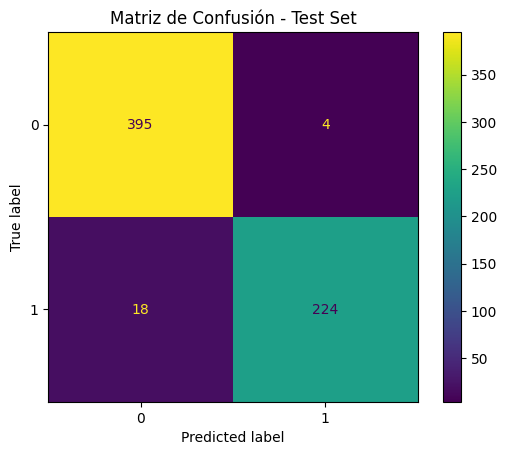

In [ ]:
ConfusionMatrixDisplay.from_estimator(modelo, X_test, y_test)
plt.title("Matriz de Confusión - Test Set")
plt.show()

##Visualizacion del Arbol de Decision

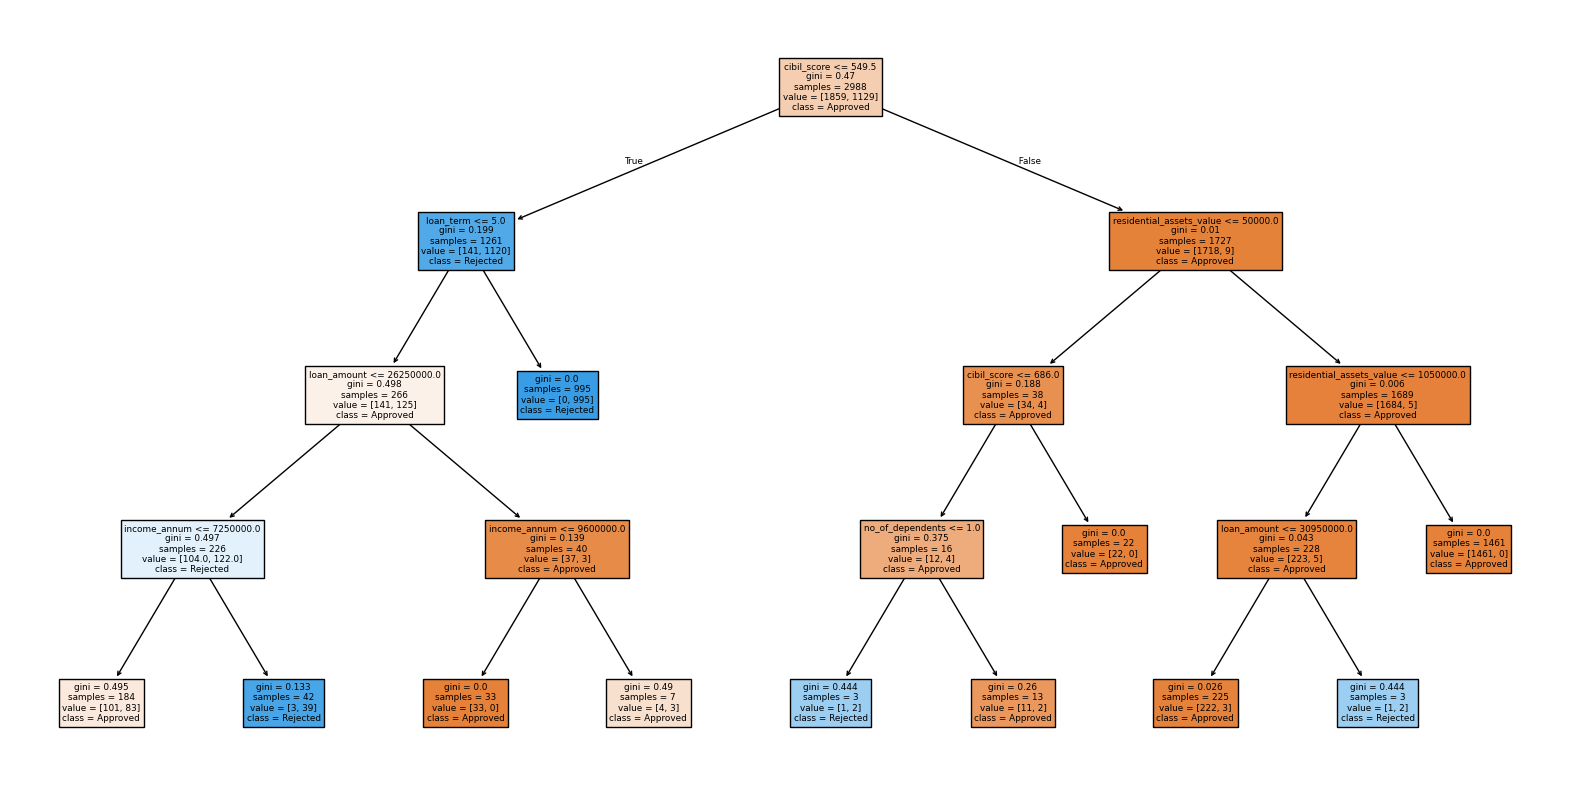

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(modelo,
          feature_names=X.columns,
          class_names=['Approved', 'Rejected'],
          filled=True)

plt.show()

# **K-Nearest Neighbors** 🔻


---

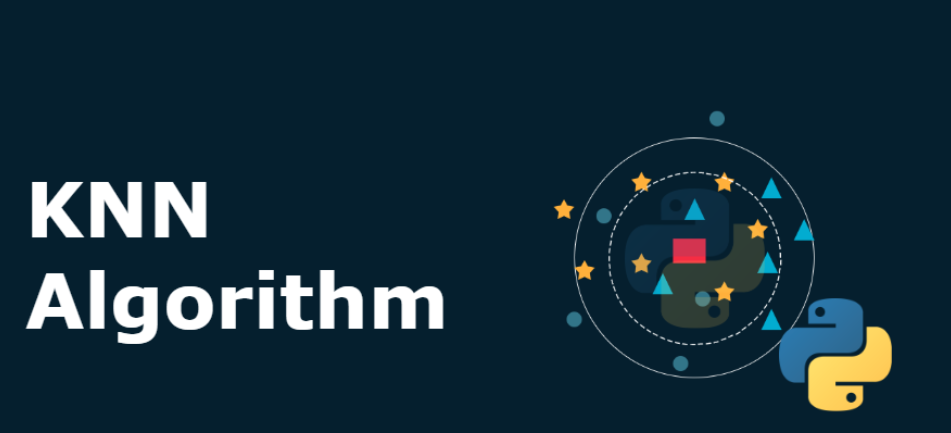

---




##Escalado de caracteristicas ✅

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

## K optimo 👌

In [ ]:
k_range = range(1, 21)
resultados_metricas = {}

for metrica in ["euclidean", "manhattan"]:
    accs = []
    for k in k_range:
        knn_temp = KNeighborsClassifier(n_neighbors=k, metric=metrica)
        knn_temp.fit(X_train_scaled, y_train)
        accs.append(accuracy_score(y_val, knn_temp.predict(X_val_scaled)))
    resultados_metricas[metrica] = accs

                                                        Euclidean vs Manhattan

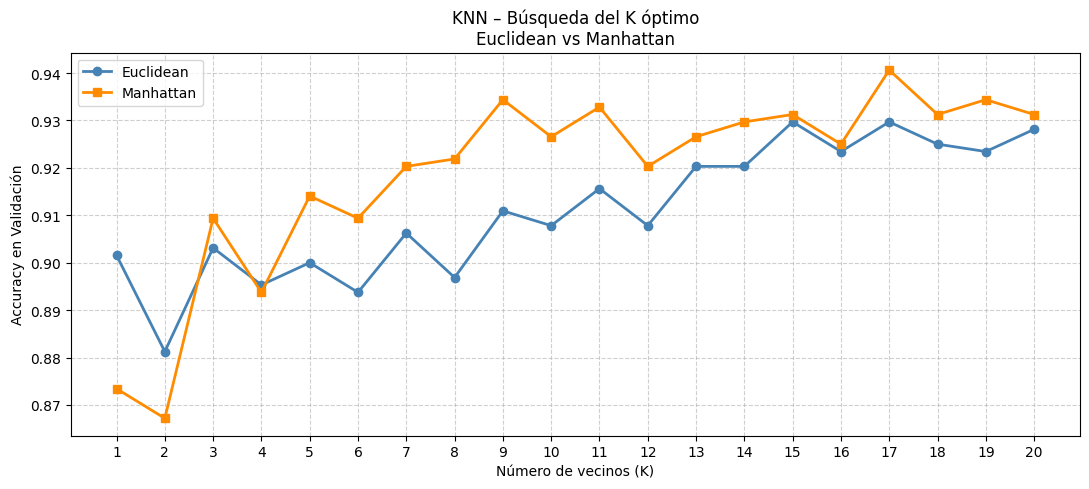

In [ ]:
plt.figure(figsize=(11, 5))
plt.plot(k_range, resultados_metricas["euclidean"], marker='o',
         color='steelblue', linewidth=2, label="Euclidean")
plt.plot(k_range, resultados_metricas["manhattan"], marker='s',
         color='darkorange', linewidth=2, label="Manhattan")
plt.xlabel("Número de vecinos (K)")
plt.ylabel("Accuracy en Validación")
plt.title("KNN – Búsqueda del K óptimo\nEuclidean vs Manhattan")
plt.xticks(k_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
# Seleccionar la combinación (métrica, K) con mayor accuracy en validación
mejor_acc   = -1
k_optimo    = None
metrica_opt = None

for metrica, accs in resultados_metricas.items():
    idx = int(np.argmax(accs))
    if accs[idx] > mejor_acc:
        mejor_acc   = accs[idx]
        k_optimo    = k_range[idx]
        metrica_opt = metrica

print(f"  Mejor métrica : {metrica_opt}")
print(f"  K óptimo      : {k_optimo}")
print(f"  Accuracy val  : {mejor_acc:.4f}")

  Mejor métrica : manhattan
  K óptimo      : 17
  Accuracy val  : 0.9406


##Train con K optimo 📈

In [ ]:
knn = KNeighborsClassifier(n_neighbors=k_optimo, metric=metrica_opt)
knn.fit(X_train_scaled, y_train)
knn

KNeighborsClassifier(metric='manhattan', n_neighbors=17)

##Tiempos ⏲

In [ ]:
t0 = time.time()
# reentrenamiento solo para medir tiempo
knn.fit(X_train_scaled, y_train)
tiempo_train_knn = time.time() - t0

t0 = time.time()
y_test_knn = knn.predict(X_test_scaled)
tiempo_pred_knn = time.time() - t0

print(f"\nKNN  –  Tiempo entrenamiento : {tiempo_train_knn:.4f} s")
print(f"KNN  –  Tiempo predicción    : {tiempo_pred_knn:.4f} s")


KNN  –  Tiempo entrenamiento : 0.0070 s
KNN  –  Tiempo predicción    : 0.0505 s


                                Reeentrenamiento del arbol para medir el tiempo




In [ ]:
t0 = time.time()
modelo.fit(X_train, y_train)
tiempo_train_arbol = time.time() - t0

t0 = time.time()
y_test_pred = modelo.predict(X_test)
tiempo_pred_arbol = time.time() - t0

print(f"\nÁrbol–  Tiempo entrenamiento : {tiempo_train_arbol:.4f} s")
print(f"Árbol–  Tiempo predicción    : {tiempo_pred_arbol:.4f} s")



Árbol–  Tiempo entrenamiento : 0.0108 s
Árbol–  Tiempo predicción    : 0.0018 s


##Evaluacion validacion ✔

In [ ]:
y_val_knn = knn.predict(X_val_scaled)

print("Accuracy Validación:", accuracy_score(y_val, y_val_knn))
print(classification_report(y_val, y_val_knn, target_names=["Approved", "Rejected"]))

Accuracy Validación: 0.940625
              precision    recall  f1-score   support

    Approved       0.95      0.95      0.95       398
    Rejected       0.92      0.93      0.92       242

    accuracy                           0.94       640
   macro avg       0.94      0.94      0.94       640
weighted avg       0.94      0.94      0.94       640



##Evaluacion Test ✔

In [ ]:
print("Accuracy Test:", accuracy_score(y_test, y_test_knn))
print(classification_report(y_test, y_test_knn, target_names=["Approved", "Rejected"]))


Accuracy Test: 0.9188767550702028
              precision    recall  f1-score   support

    Approved       0.92      0.95      0.94       399
    Rejected       0.92      0.86      0.89       242

    accuracy                           0.92       641
   macro avg       0.92      0.91      0.91       641
weighted avg       0.92      0.92      0.92       641



##Matriz Confusion 🔎

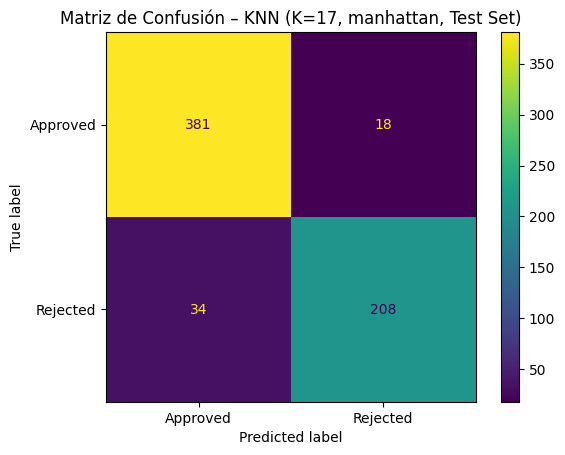

In [ ]:
ConfusionMatrixDisplay.from_estimator(knn, X_test_scaled, y_test,
                                       display_labels=["Approved", "Rejected"])
plt.title(f"Matriz de Confusión – KNN (K={k_optimo}, {metrica_opt}, Test Set)")
plt.show()

##Curvas ROC y AUC – Arbol de decision ***vs*** KNN 🔎

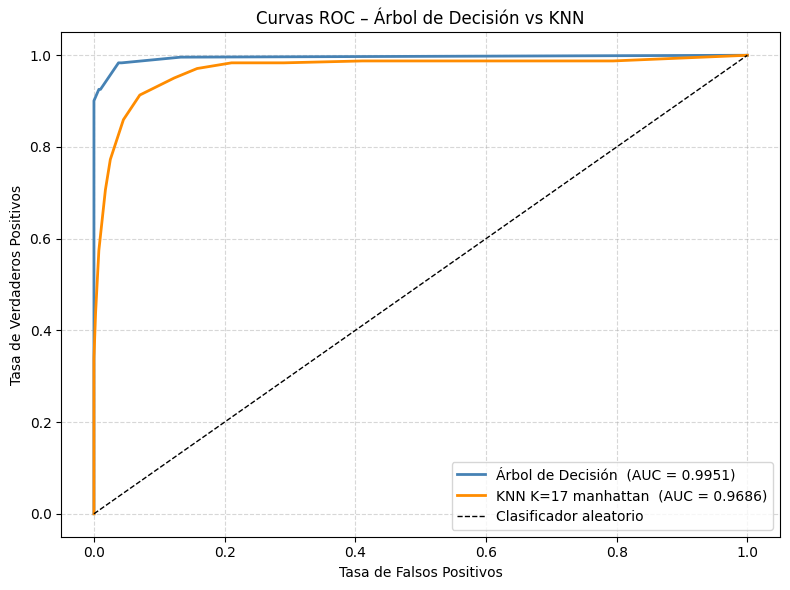

In [ ]:
# Probabilidades de la clase positiva
prob_arbol = modelo.predict_proba(X_test)[:, 1]
prob_knn   = knn.predict_proba(X_test_scaled)[:, 1]

fpr_a, tpr_a, _ = roc_curve(y_test, prob_arbol)
fpr_k, tpr_k, _ = roc_curve(y_test, prob_knn)

auc_arbol = roc_auc_score(y_test, prob_arbol)
auc_knn   = roc_auc_score(y_test, prob_knn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_a, tpr_a, color='steelblue',  linewidth=2,
         label=f"Árbol de Decisión  (AUC = {auc_arbol:.4f})")
plt.plot(fpr_k, tpr_k, color='darkorange', linewidth=2,
         label=f"KNN K={k_optimo} {metrica_opt}  (AUC = {auc_knn:.4f})")
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label="Clasificador aleatorio")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Curvas ROC – Árbol de Decisión vs KNN")
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

##Resumen de metricas – Test Set 🗒

In [ ]:
def metricas_completas(y_true, y_pred, y_prob, nombre, t_train, t_pred):
    return {
        "Modelo":        nombre,
        "Accuracy":      round(accuracy_score(y_true, y_pred), 4),
        "Precision":     round(precision_score(y_true, y_pred, average="weighted"), 4),
        "Recall":        round(recall_score(y_true, y_pred, average="weighted"), 4),
        "F1-Score":      round(f1_score(y_true, y_pred, average="weighted"), 4),
        "AUC-ROC":       round(roc_auc_score(y_true, y_prob), 4),
        "T. Train (s)":  round(t_train, 4),
        "T. Pred  (s)":  round(t_pred, 4),
    }

tabla = pd.DataFrame([
    metricas_completas(y_test, y_test_pred, prob_arbol,
                       "Árbol de Decisión",
                       tiempo_train_arbol, tiempo_pred_arbol),
    metricas_completas(y_test, y_test_knn,  prob_knn,
                       f"KNN (K={k_optimo}, {metrica_opt})",
                       tiempo_train_knn,   tiempo_pred_knn),
])


print("COMPARACIÓN FINAL – TEST SET")

print(tabla.to_string(index=False))

COMPARACIÓN FINAL – TEST SET
               Modelo  Accuracy  Precision  Recall  F1-Score  AUC-ROC  T. Train (s)  T. Pred  (s)
    Árbol de Decisión    0.9657     0.9662  0.9657    0.9655   0.9951        0.0108        0.0018
KNN (K=17, manhattan)    0.9189     0.9189  0.9189    0.9183   0.9686        0.0070        0.0505


##Grafico de barras - Comparacion metricas 📊

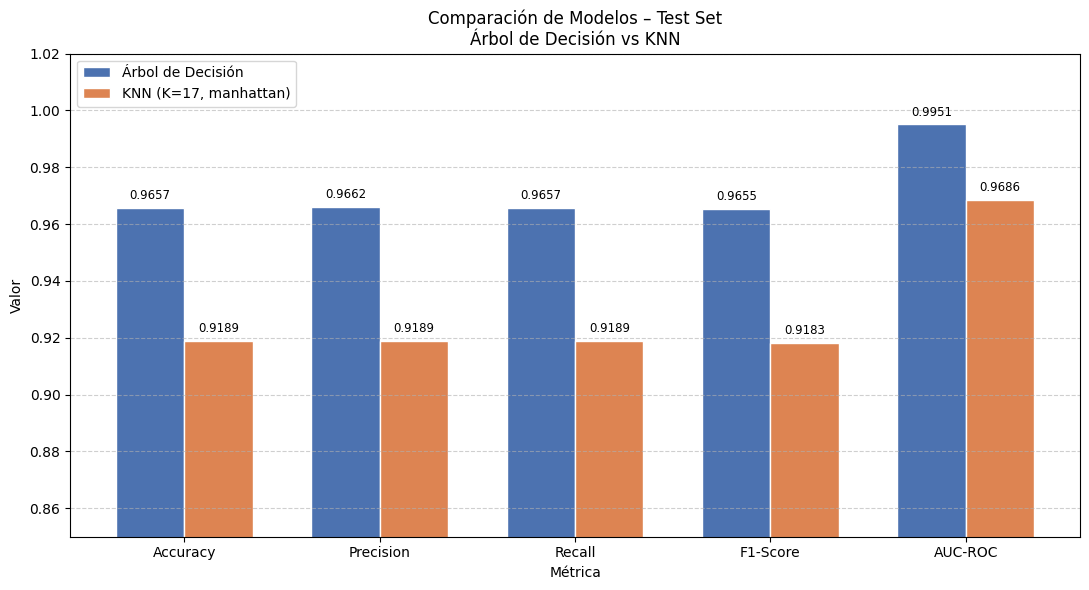

In [ ]:
metricas_grafico = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]
arbol_vals = tabla[tabla["Modelo"] == "Árbol de Decisión"][metricas_grafico].values[0]
knn_vals   = tabla[tabla["Modelo"] == f"KNN (K={k_optimo}, {metrica_opt})"][metricas_grafico].values[0]

x     = np.arange(len(metricas_grafico))
ancho = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x - ancho/2, arbol_vals, ancho, label="Árbol de Decisión",
            color="#4C72B0", edgecolor="white")
b2 = ax.bar(x + ancho/2, knn_vals,   ancho,
            label=f"KNN (K={k_optimo}, {metrica_opt})",
            color="#DD8452", edgecolor="white")

ax.set_xlabel("Métrica")
ax.set_ylabel("Valor")
ax.set_title("Comparación de Modelos – Test Set\nÁrbol de Decisión vs KNN")
ax.set_xticks(x)
ax.set_xticklabels(metricas_grafico)
ax.set_ylim(0.85, 1.02)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.6)

for barra in list(b1) + list(b2):
    h = barra.get_height()
    ax.annotate(f"{h:.4f}",
                xy=(barra.get_x() + barra.get_width() / 2, h),
                xytext=(0, 4), textcoords="offset points",
                ha="center", va="bottom", fontsize=8.5)

plt.tight_layout()
plt.show()


## Comparacion de tiempos – Entrenamiento y Prediccion 📊

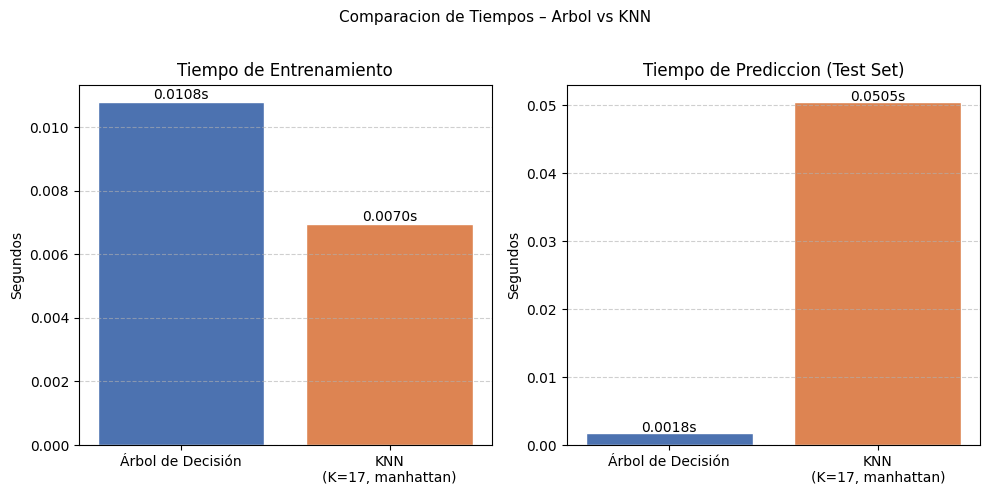

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
modelos_nombres = ["Árbol de Decisión", f"KNN\n(K={k_optimo}, {metrica_opt})"]
colores = ["#4C72B0", "#DD8452"]

# Tiempo entrenamiento
axes[0].bar(modelos_nombres,
            [tiempo_train_arbol, tiempo_train_knn],
            color=colores, edgecolor="white")
axes[0].set_title("Tiempo de Entrenamiento")
axes[0].set_ylabel("Segundos")
axes[0].grid(axis="y", linestyle="--", alpha=0.6)
for i, v in enumerate([tiempo_train_arbol, tiempo_train_knn]):
    axes[0].text(i, v + 0.0001, f"{v:.4f}s", ha="center", fontsize=10)

# Tiempo predicción
axes[1].bar(modelos_nombres,
            [tiempo_pred_arbol, tiempo_pred_knn],
            color=colores, edgecolor="white")
axes[1].set_title("Tiempo de Prediccion (Test Set)")
axes[1].set_ylabel("Segundos")
axes[1].grid(axis="y", linestyle="--", alpha=0.6)
for i, v in enumerate([tiempo_pred_arbol, tiempo_pred_knn]):
    axes[1].text(i, v + 0.0001, f"{v:.4f}s", ha="center", fontsize=10)

plt.suptitle("Comparacion de Tiempos – Arbol vs KNN\n",
             fontsize=11)
plt.tight_layout()
plt.show()